In [2]:
!pip install medmnist torch torchvision matplotlib
!pip install torchinfo


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.4 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=f

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, roc_curve, auc

from medmnist import OCTMNIST
from torchinfo import summary

In [22]:
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

CUDA Available: True


In [ ]:
octmnist_train = OCTMNIST(split="train", download=True)
octmnist_test = OCTMNIST(split="test", download=True)
octmnist_val = OCTMNIST(split="val", download=True)


100%|██████████| 54.9M/54.9M [00:03<00:00, 15.4MB/s]


Using downloaded and verified file: /root/.medmnist/octmnist.npz
Using downloaded and verified file: /root/.medmnist/octmnist.npz


In [ ]:
images = np.concatenate([octmnist_train.imgs, octmnist_val.imgs, octmnist_test.imgs], axis=0)
labels = np.concatenate([octmnist_train.labels, octmnist_val.labels, octmnist_test.labels], axis=0)

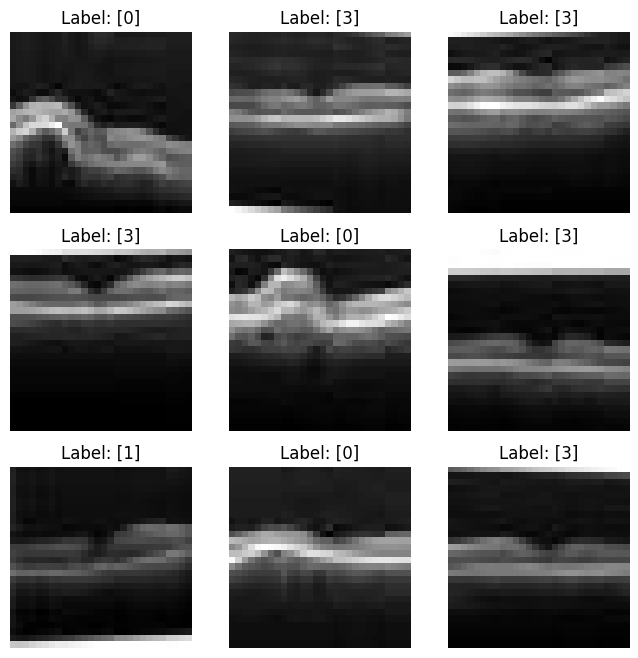

Dataset Analysis:
Total number of samples: 109309
Image shape: (28, 28)
Number of unique classes: 4
Classes: [0 1 2 3]
Label distribution: {0: 37455, 1: 11598, 2: 8866, 3: 51390}
Mean pixel intensity: 48.2002
Standard deviation of pixel intensity: 50.0744


In [ ]:
total_samples = len(images)
image_shape = images[0].shape 
unique_classes = np.unique(labels)
label_distribution = {class_label: np.sum(labels == class_label) for class_label in unique_classes}

flattened_images = images.reshape(images.shape[0], -1)
mean_intensity = np.mean(flattened_images)
std_intensity = np.std(flattened_images)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img, label in zip(axes.flatten(), images[:9], labels[:9]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.show()

print("Dataset Analysis:")
print(f"Total number of samples: {total_samples}")
print(f"Image shape: {image_shape}")
print(f"Number of unique classes: {len(unique_classes)}")
print(f"Classes: {unique_classes}")
print(f"Label distribution: {label_distribution}")
print(f"Mean pixel intensity: {mean_intensity:.4f}")
print(f"Standard deviation of pixel intensity: {std_intensity:.4f}")


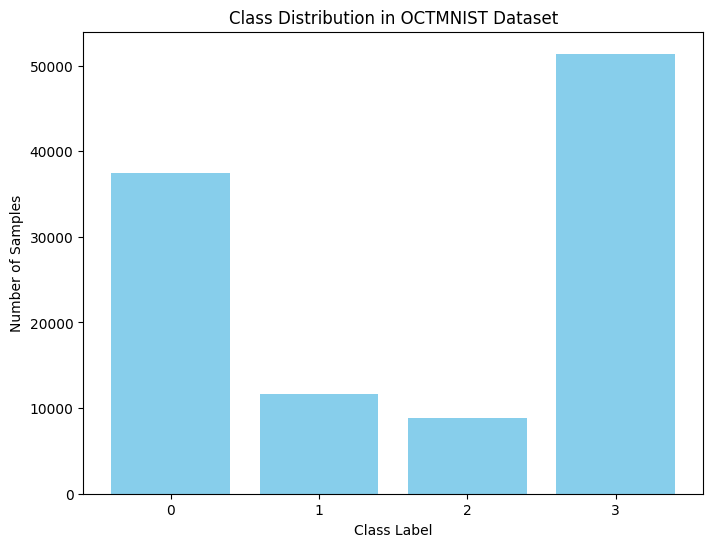

In [ ]:
import matplotlib.pyplot as plt

label_distribution = {class_label: np.sum(labels == class_label) for class_label in unique_classes}

plt.figure(figsize=(8, 6))
plt.bar(label_distribution.keys(), label_distribution.values(), color='skyblue')
plt.title("Class Distribution in OCTMNIST Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(unique_classes)
plt.show()


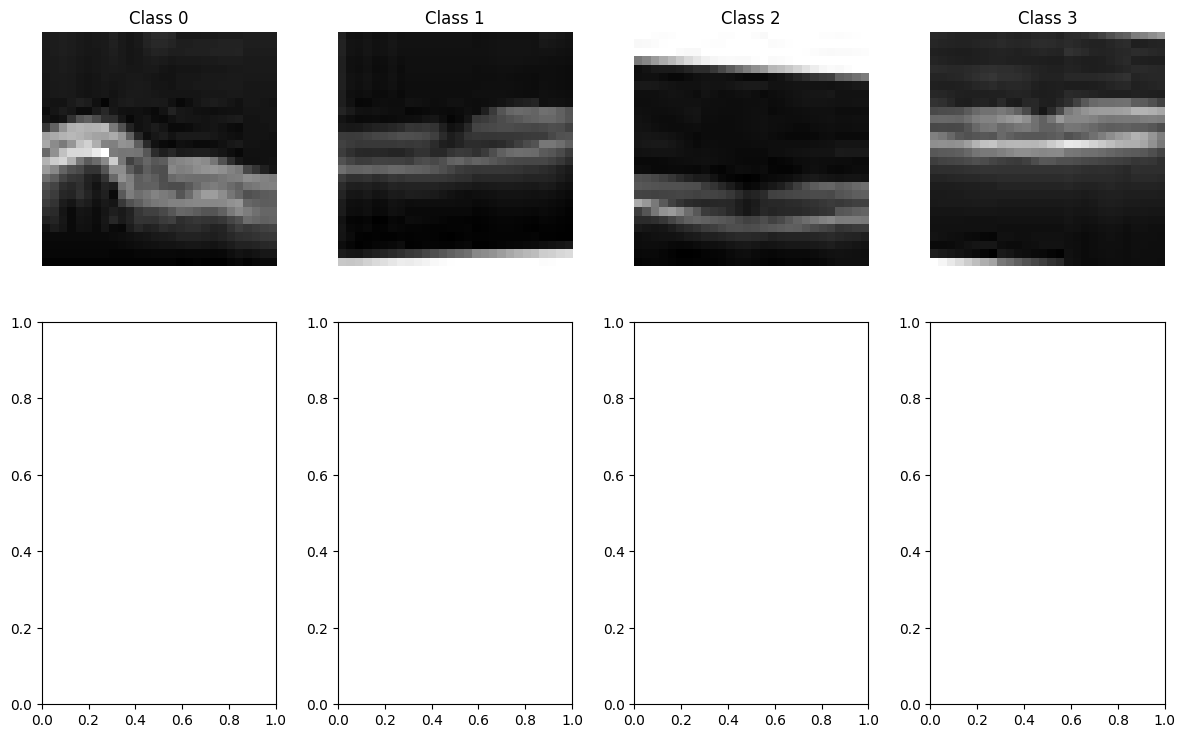

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = labels.flatten()

fig, axes = plt.subplots(2, 4, figsize=(12, 8))

for i, class_label in enumerate(unique_classes):
    class_images = images[labels == class_label]

    if class_images.shape[0] > 0:
        sample_image = class_images[0]
        ax = axes[i // 4, i % 4]

        ax.imshow(np.squeeze(sample_image), cmap='gray')
        ax.set_title(f"Class {class_label}")
        ax.axis('off')

plt.tight_layout()
plt.show()


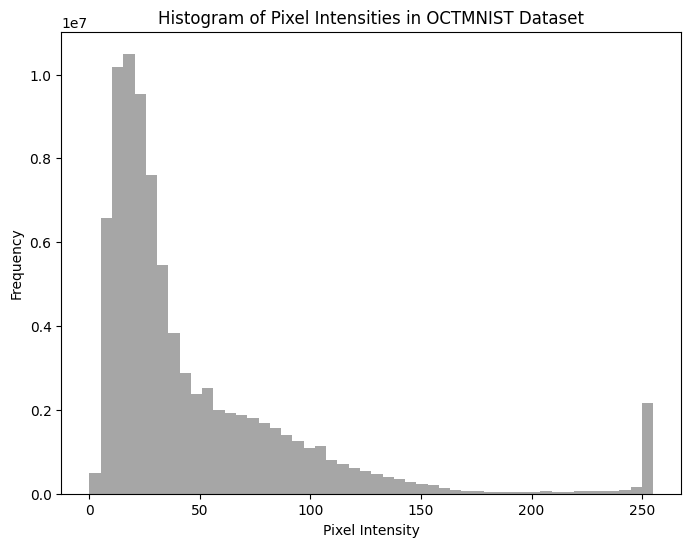

In [ ]:
flattened_images = images.reshape(images.shape[0], -1)
pixel_values = flattened_images.flatten()

plt.figure(figsize=(8, 6))
plt.hist(pixel_values, bins=50, color='gray', alpha=0.7)
plt.title("Histogram of Pixel Intensities in OCTMNIST Dataset")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


In [ ]:
from medmnist import OCTMNIST
import numpy as np
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

images = images.astype(np.float32) / 255.0 

class_counts = np.bincount(labels.flatten())
class_weights = 1.0 / class_counts 
weights = class_weights[labels.flatten()]

print(f"Sampler weights (first 10): {weights[:10]}")
print(f"Total training samples before split: {len(images)}")

train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.30, random_state=42
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=42
)

print(f"Train images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")
print(f"Test images: {len(test_images)}")

encoder = OneHotEncoder(sparse_output=False)
one_hot_train_labels = encoder.fit_transform(train_labels.reshape(-1, 1))
one_hot_val_labels = encoder.transform(val_labels.reshape(-1, 1))
one_hot_test_labels = encoder.transform(test_labels.reshape(-1, 1))

train_class_counts = np.bincount(train_labels.flatten())
train_class_weights = 1.0 / train_class_counts
train_weights = train_class_weights[train_labels.flatten()]

data_sampler = WeightedRandomSampler(train_weights, len(train_weights), replacement=True)

data_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class OCTDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, label = self.images[idx], self.labels[idx]
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  
        label = torch.tensor(label, dtype=torch.float32)  
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = OCTDataset(train_images, one_hot_train_labels, transform=data_transform)
val_dataset = OCTDataset(val_images, one_hot_val_labels, transform=data_transform)
test_dataset = OCTDataset(test_images, one_hot_test_labels, transform=data_transform)

train_dataloader = DataLoader(train_dataset, batch_size=32, sampler=data_sampler, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Dataset Preprocessing Complete")
print(f"Total samples: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print(f"Class distribution (original): {class_counts}")

Sampler weights (first 10): [2.66987051e-05 1.94590387e-05 1.94590387e-05 1.94590387e-05
 2.66987051e-05 1.94590387e-05 8.62217624e-05 2.66987051e-05
 1.94590387e-05 1.94590387e-05]
Total training samples before split: 109309
Train images: 76516
Validation images: 16396
Test images: 16397
Dataset Preprocessing Complete
Total samples: 109309
Training samples: 76516
Validation samples: 16396
Testing samples: 16397
Class distribution (original): [37455 11598  8866 51390]


## Base Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchinfo import summary

class CustomCNNModel(nn.Module):
    def __init__(self):
        super(CustomCNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 3 * 3, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 4)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2) 
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)
        x = x.view(-1, 64 * 3 * 3) 
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


model = CustomCNNModel()
summary(model, input_size=(32, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CustomCNNModel                           [32, 4]                   --
├─Conv2d: 1-1                            [32, 16, 28, 28]          160
├─Conv2d: 1-2                            [32, 32, 14, 14]          4,640
├─Conv2d: 1-3                            [32, 64, 7, 7]            18,496
├─Linear: 1-4                            [32, 256]                 147,712
├─Dropout: 1-5                           [32, 256]                 --
├─Linear: 1-6                            [32, 4]                   1,028
Total params: 172,036
Trainable params: 172,036
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 66.88
Input size (MB): 0.10
Forward/backward pass size (MB): 5.69
Params size (MB): 0.69
Estimated Total Size (MB): 6.47

## Using CrossEntropyLoss function

In [ ]:
import torch
import time
import numpy as np
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)

loss_function = torch.nn.CrossEntropyLoss() 
optimizer = Adam(model.parameters(), lr=0.005)

epochs = 10
start_time = time.time()

patience = 3
best_val_loss = np.inf
epochs_no_improve = 0
epoch_time_ce = 0

train_losses_ce, val_losses_ce = [], []
train_accuracies_ce, val_accuracies_ce = [], []

for epoch in range(epochs):
    model.train()  
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in train_dataloader:

        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  

        if labels.ndimension() > 1:  
            labels = torch.argmax(labels, dim=1)  


        outputs = model(inputs)  

        loss = loss_function(outputs, labels) 

        loss.backward()  

        optimizer.step() 

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = 100 * correct_predictions / total_predictions
    train_losses_ce.append(train_loss)
    train_accuracies_ce.append(train_accuracy)

    model.eval() 
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():  
        for val_inputs, val_labels in val_dataloader:

            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            if val_labels.ndimension() > 1: 
                val_labels = torch.argmax(val_labels, dim=1) 

            val_outputs = model(val_inputs)  
            loss = loss_function(val_outputs, val_labels) 

            val_loss += loss.item()

            _, predicted = torch.max(val_outputs, 1)
            total_predictions += val_labels.size(0)
            correct_predictions += (predicted == val_labels).sum().item()

    val_loss = val_loss / len(val_dataloader)
    val_accuracy = 100 * correct_predictions / total_predictions
    val_losses_ce.append(val_loss)
    val_accuracies_ce.append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_cross.pth")

    epoch_time_ce = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}% || Time: {epoch_time_ce//60:.0f}m {epoch_time_ce%60:.0f}s")

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time // 60:.0f}m {training_time % 60:.0f}s")



Using device: cuda
Epoch [1/10] Training Loss: 0.6728, Training Accuracy: 73.34%
Validation Loss: 0.6247, Validation Accuracy: 74.65% || Time: 0m 32s
Epoch [2/10] Training Loss: 0.6717, Training Accuracy: 73.50%
Validation Loss: 0.5847, Validation Accuracy: 76.60% || Time: 1m 5s
Epoch [3/10] Training Loss: 0.6655, Training Accuracy: 73.77%
Validation Loss: 0.5430, Validation Accuracy: 80.95% || Time: 1m 37s
Epoch [4/10] Training Loss: 0.6712, Training Accuracy: 73.69%
Validation Loss: 0.5896, Validation Accuracy: 76.71% || Time: 2m 10s
Epoch [5/10] Training Loss: 0.6666, Training Accuracy: 73.79%
Validation Loss: 0.6283, Validation Accuracy: 74.94% || Time: 2m 42s
Epoch [6/10] Training Loss: 0.6620, Training Accuracy: 74.05%
Validation Loss: 0.5970, Validation Accuracy: 77.57% || Time: 3m 14s
Epoch [7/10] Training Loss: 0.6638, Training Accuracy: 73.65%
Validation Loss: 0.5278, Validation Accuracy: 82.12% || Time: 3m 47s
Epoch [8/10] Training Loss: 0.6639, Training Accuracy: 74.04%
Val

In [ ]:
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

# Load model
model.load_state_dict(torch.load("best_model_cross.pth", map_location=device), strict=False)
model.to(device)
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

all_logits = []
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for test_inputs, test_labels in test_dataloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        if test_labels.ndimension() > 1:
            true_labels = torch.argmax(test_labels, dim=1)
        else:
            true_labels = test_labels

        test_outputs = model(test_inputs)
        loss = loss_function(test_outputs, true_labels)
        test_loss += loss.item()

        _, predicted = torch.max(test_outputs, 1)

        total_predictions += true_labels.size(0)
        correct_predictions += (predicted == true_labels).sum().item()

        all_logits.append(test_outputs.cpu().numpy()) 
        all_true_labels.extend(true_labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())

test_predictions = np.vstack(all_logits)
test_labels = np.array(all_true_labels)

test_accuracy = 100 * correct_predictions / total_predictions
test_loss = test_loss / len(test_dataloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predicted_labels, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Shape of test_predictions: {test_predictions.shape}")

<ipython-input-56-dcf30fd3cdcf>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_cross.pth", map_location=device), strict=False)

Test Loss: 0.5496
Test Accuracy: 81.30%
Precision: 0.6991
Recall: 0.7450
F1 Score: 0.7144
Shape of test_predictions: (14622, 4)


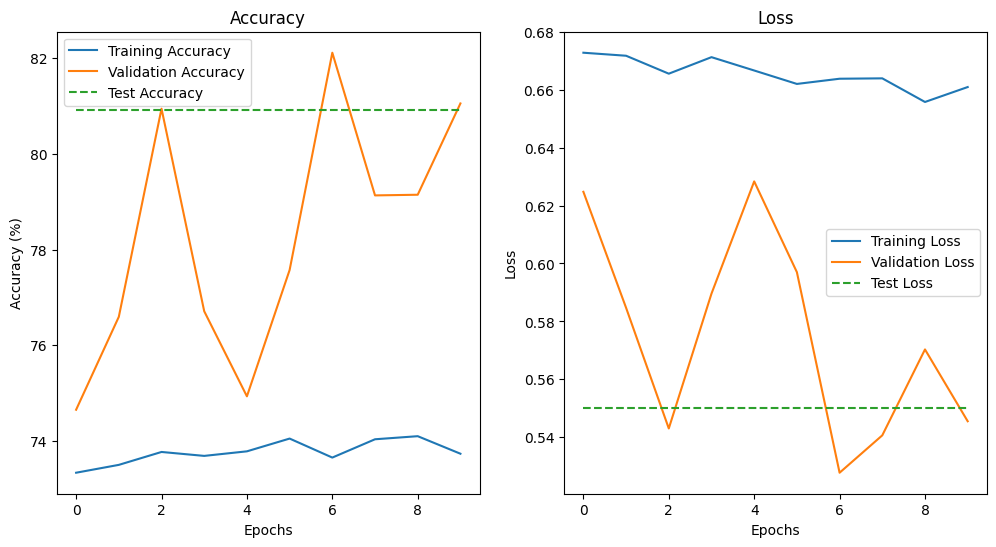

In [ ]:
import matplotlib.pyplot as plt

test_accuracy_per_epoch_ce = [test_accuracy] * epochs  
test_loss_per_epoch_ce = [test_loss] * epochs 
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_accuracies_ce, label="Training Accuracy")
plt.plot(range(epochs), val_accuracies_ce, label="Validation Accuracy")
plt.plot(range(epochs), test_accuracy_per_epoch_ce, label="Test Accuracy", linestyle='--') 
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_losses_ce, label="Training Loss")
plt.plot(range(epochs), val_losses_ce, label="Validation Loss")
plt.plot(range(epochs), test_loss_per_epoch_ce, label="Test Loss", linestyle='--')  # Test loss line
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


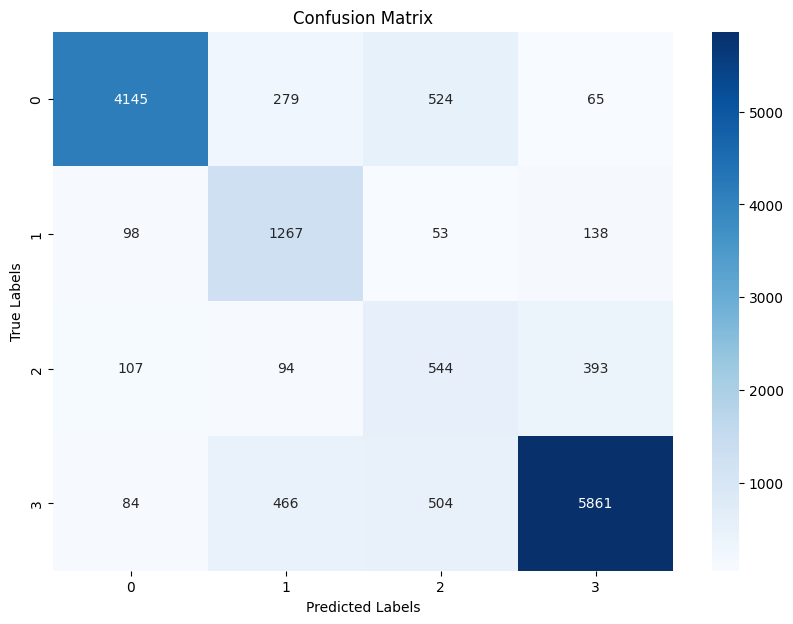

In [ ]:
test_labels = []
test_predictions = []

with torch.no_grad():
    for test_inputs, test_labels_batch in test_dataloader:
        test_inputs, test_labels_batch = test_inputs.to(device), test_labels_batch.to(device)

        test_labels_batch = torch.argmax(test_labels_batch, dim=1)
        test_outputs = model(test_inputs)
        _, predicted = torch.max(test_outputs, 1)

        test_labels.extend(test_labels_batch.cpu().numpy()) 
        test_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [ ]:
import torch.nn.functional as F
import numpy as np

test_predictions = np.array(test_predictions)

print(f"Shape of test_predictions before softmax: {test_predictions.shape}")

Shape of test_predictions before softmax: (14622, 4)


In [ ]:
test_predictions = F.softmax(torch.tensor(test_predictions), dim=1).numpy()


print(f"Shape of test_predictions after softmax: {test_predictions.shape}")

import torch.nn.functional as F
import numpy as np

test_predictions = np.array(test_predictions)

print(test_predictions[0])

test_predictions = F.softmax(torch.tensor(test_predictions), dim=1).numpy()

predicted_class = np.argmax(test_predictions[0])


Shape of test_predictions after softmax: (14622, 4)
[0.23211096 0.2337106  0.23647869 0.29769972]
[0.24547312 0.2458661  0.24654761 0.26211312]


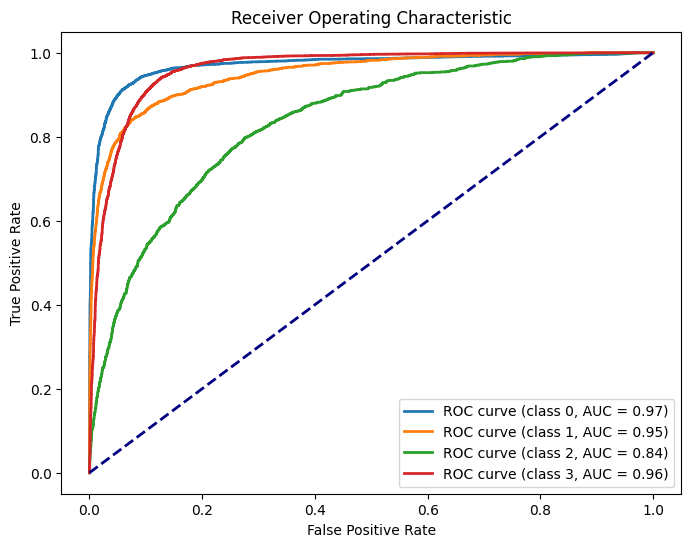

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

test_labels_binarized = label_binarize(test_labels, classes=np.arange(test_predictions.shape[1]))
n_classes = test_labels_binarized.shape[1]

fpr, tpr, thresholds, roc_auc = {}, {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels_binarized[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve (class {i}, AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


## New Loss Function (Focal Loss)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

model_focal = CustomCNNModel()
model_focal = model_focal.to(device)

loss_function = FocalLoss(alpha=1, gamma=2, reduction='mean')
optimizer = optim.Adam(model_focal.parameters(), lr=0.001)

epochs = 10
start_time = time.time()

patience = 3
best_val_loss = np.inf
epochs_no_improve = 0

train_losses_focal, val_losses_focal = [], []
train_accuracies_focal, val_accuracies_focal = [], []

for epoch in range(epochs):
    model_focal.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        if labels.ndimension() > 1:
            labels = torch.argmax(labels, dim=1)

        optimizer.zero_grad()
        outputs = model_focal(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = 100 * correct_predictions / total_predictions
    train_losses_focal.append(train_loss)
    train_accuracies_focal.append(train_accuracy)

    model_focal.eval()
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            if val_labels.ndimension() > 1:
                val_labels = torch.argmax(val_labels, dim=1)

            val_outputs = model_focal(val_inputs)
            loss = loss_function(val_outputs, val_labels)
            val_loss += loss.item()

            _, predicted = torch.max(val_outputs, 1)
            total_predictions += val_labels.size(0)
            correct_predictions += (predicted == val_labels).sum().item()

    val_loss = val_loss / len(val_dataloader)
    val_accuracy = 100 * correct_predictions / total_predictions
    val_losses_focal.append(val_loss)
    val_accuracies_focal.append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_focal.state_dict(), "best_model_focal.pth")

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_accuracy:.2f}% || Time: {epoch_time//60:.0f}m {epoch_time%60:.0f}s")

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time // 60:.0f}m {training_time % 60:.0f}s")


Epoch [1/10] - Train Loss: 0.4078, Train Acc: 63.71%
Validation Loss: 0.3030, Validation Acc: 74.78% || Time: 0m 33s
Epoch [2/10] - Train Loss: 0.2773, Train Acc: 74.13%
Validation Loss: 0.2599, Validation Acc: 77.65% || Time: 1m 6s
Epoch [3/10] - Train Loss: 0.2441, Train Acc: 76.43%
Validation Loss: 0.1872, Validation Acc: 83.59% || Time: 1m 40s
Epoch [4/10] - Train Loss: 0.2166, Train Acc: 78.60%
Validation Loss: 0.1746, Validation Acc: 83.83% || Time: 2m 14s
Epoch [5/10] - Train Loss: 0.1970, Train Acc: 79.68%
Validation Loss: 0.1669, Validation Acc: 84.13% || Time: 2m 46s
Epoch [6/10] - Train Loss: 0.1863, Train Acc: 80.52%
Validation Loss: 0.1724, Validation Acc: 83.24% || Time: 3m 20s
Epoch [7/10] - Train Loss: 0.1761, Train Acc: 81.31%
Validation Loss: 0.1689, Validation Acc: 82.24% || Time: 3m 53s
Epoch [8/10] - Train Loss: 0.1700, Train Acc: 82.11%
Validation Loss: 0.1533, Validation Acc: 84.49% || Time: 4m 26s
Epoch [9/10] - Train Loss: 0.1612, Train Acc: 82.54%
Validation L

In [ ]:
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

model.load_state_dict(torch.load("best_model_focal.pth", map_location=device), strict=False)
model.to(device)
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

all_logits = []
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for test_inputs, test_labels in test_dataloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        if test_labels.ndimension() > 1:
            true_labels = torch.argmax(test_labels, dim=1)
        else:
            true_labels = test_labels

        test_outputs = model(test_inputs)
        loss = loss_function(test_outputs, true_labels)
        test_loss += loss.item()

        _, predicted = torch.max(test_outputs, 1)

        total_predictions += true_labels.size(0)
        correct_predictions += (predicted == true_labels).sum().item()

        all_logits.append(test_outputs.cpu().numpy())
        all_true_labels.extend(true_labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())

test_predictions = np.vstack(all_logits)
test_labels = np.array(all_true_labels)

test_accuracy = 100 * correct_predictions / total_predictions
test_loss = test_loss / len(test_dataloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predicted_labels, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Shape of test_predictions: {test_predictions.shape}")

<ipython-input-69-a992f499249e>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_focal.pth", map_location=device), strict=False)

Test Loss: 0.1640
Test Accuracy: 84.17%
Precision: 0.7621
Recall: 0.8113
F1 Score: 0.7716
Shape of test_predictions: (14622, 4)


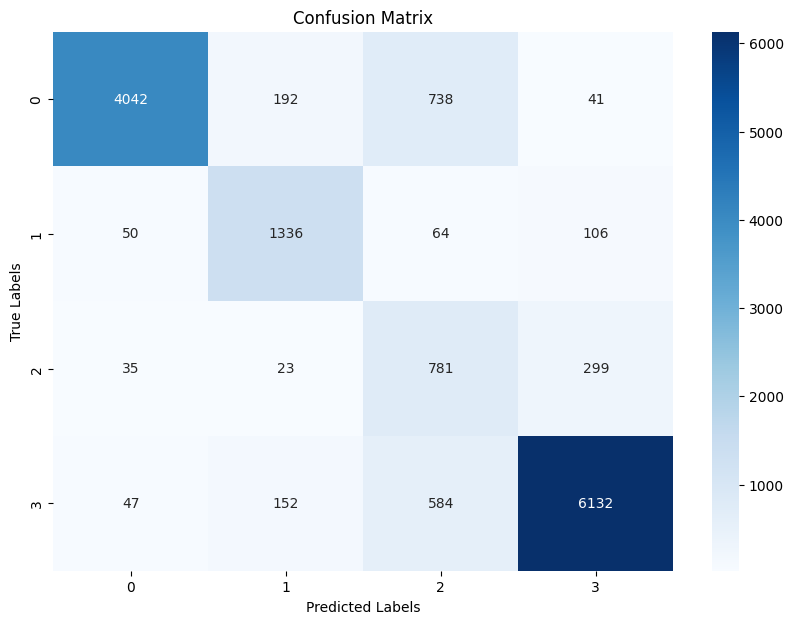

In [ ]:
test_labels = []
test_predictions = []

with torch.no_grad():
    for test_inputs, test_labels_batch in test_dataloader:
        test_inputs, test_labels_batch = test_inputs.to(device), test_labels_batch.to(device)

        test_labels_batch = torch.argmax(test_labels_batch, dim=1)
        test_outputs = model(test_inputs)
        _, predicted = torch.max(test_outputs, 1)

        test_labels.extend(test_labels_batch.cpu().numpy())
        test_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


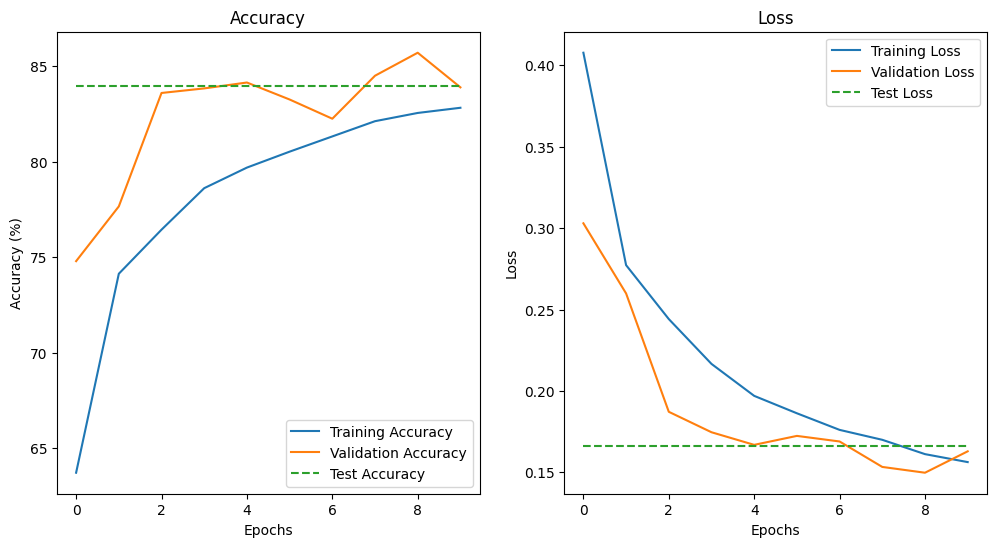

In [ ]:
import matplotlib.pyplot as plt

test_accuracy_per_epoch_focal = [test_accuracy] * epochs  
test_loss_per_epoch_focal = [test_loss] * epochs  

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_accuracies_focal, label="Training Accuracy")
plt.plot(range(epochs), val_accuracies_focal, label="Validation Accuracy")
plt.plot(range(epochs), test_accuracy_per_epoch_focal, label="Test Accuracy", linestyle='--')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_losses_focal, label="Training Loss")
plt.plot(range(epochs), val_losses_focal, label="Validation Loss")
plt.plot(range(epochs), test_loss_per_epoch_focal, label="Test Loss", linestyle='--')  
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [ ]:
test_predictions = F.softmax(torch.tensor(test_predictions), dim=1).numpy()

print(f"Shape of test_predictions after softmax: {test_predictions.shape}")

import torch.nn.functional as F
import numpy as np

test_predictions = np.array(test_predictions)

print(test_predictions[0])

test_predictions = F.softmax(torch.tensor(test_predictions), dim=1).numpy()

predicted_class = np.argmax(test_predictions[0])


Shape of test_predictions after softmax: (14622, 4)
[1.9459228e-05 3.1928050e-03 3.0730122e-01 6.8948644e-01]


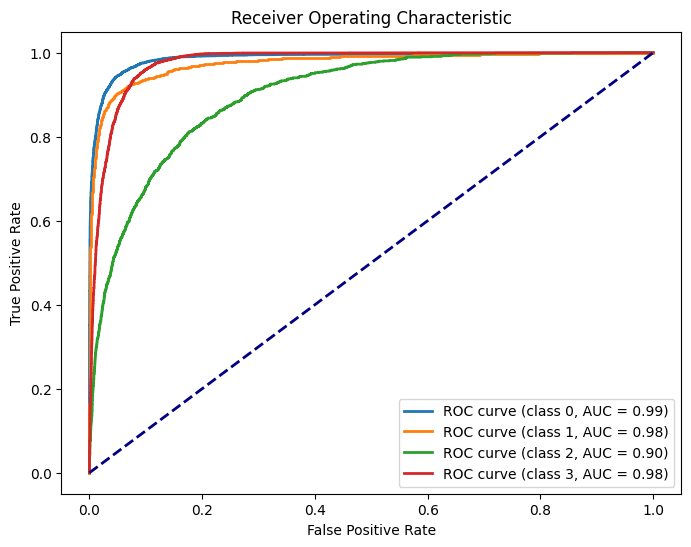

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

test_labels_binarized = label_binarize(test_labels, classes=np.arange(test_predictions.shape[1]))
n_classes = test_labels_binarized.shape[1]

fpr, tpr, thresholds, roc_auc = {}, {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(test_labels_binarized[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve (class {i}, AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


## Comparison of Training, Validation and Testing accuracy between different loss functions

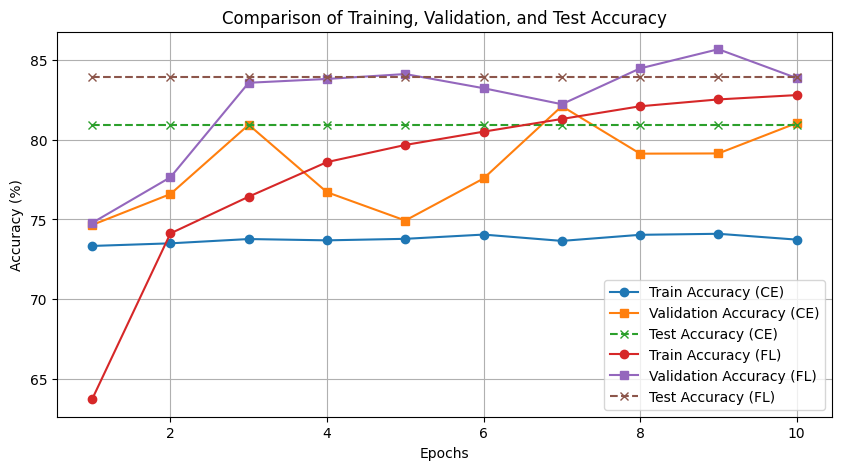

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(range(1, epochs+1), train_accuracies_ce, label='Train Accuracy (CE)', marker='o')
plt.plot(range(1, epochs+1), val_accuracies_ce, label='Validation Accuracy (CE)', marker='s')
plt.plot(range(1, epochs+1), test_accuracy_per_epoch_ce, label='Test Accuracy (CE)', linestyle='dashed', marker='x')

plt.plot(range(1, epoch+2), train_accuracies_focal, label='Train Accuracy (FL)', marker='o')
plt.plot(range(1, epoch+2), val_accuracies_focal, label='Validation Accuracy (FL)', marker='s')
plt.plot(range(1, epoch+2), test_accuracy_per_epoch_focal, label='Test Accuracy (FL)', linestyle='dashed', marker='x')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Training, Validation, and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


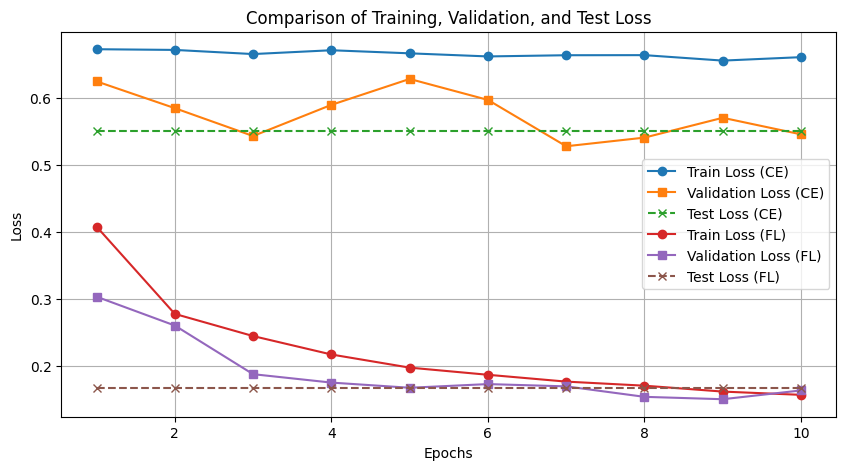

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(range(1, epochs+1), train_losses_ce, label='Train Loss (CE)', marker='o')
plt.plot(range(1, epochs+1), val_losses_ce, label='Validation Loss (CE)', marker='s')
plt.plot(range(1, epochs+1), test_loss_per_epoch_ce, label='Test Loss (CE)', linestyle='dashed', marker='x')

plt.plot(range(1, epoch+2), train_losses_focal, label='Train Loss (FL)', marker='o')
plt.plot(range(1, epoch+2), val_losses_focal, label='Validation Loss (FL)', marker='s')
plt.plot(range(1, epoch+2), test_loss_per_epoch_focal, label='Test Loss (FL)', linestyle='dashed', marker='x')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Comparison of Training, Validation, and Test Loss')
plt.legend()
plt.grid(True)
plt.show()


## Using Early Stopping method

In [ ]:
import torch
import time
import numpy as np
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_early = CustomCNNModel()
model_early = model_early.to(device)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = Adam(model_early.parameters(), lr=0.001)

epochs = 20
start_time = time.time()

patience = 3
best_val_loss = np.inf
epochs_no_improve = 0
epoch_time_early = 0

train_losses_early, val_losses_early = [], []
train_accuracies_early, val_accuracies_early = [], []

for epoch in range(epochs):
    model_early.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        if labels.ndimension() > 1:
            labels = torch.argmax(labels, dim=1)

        outputs = model_early(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = 100 * correct_predictions / total_predictions
    train_losses_early.append(train_loss)
    train_accuracies_early.append(train_accuracy)

    model_early.eval()
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            if val_labels.ndimension() > 1:
                val_labels = torch.argmax(val_labels, dim=1)

            val_outputs = model_early(val_inputs)
            loss = loss_function(val_outputs, val_labels)
            val_loss += loss.item()

            _, predicted = torch.max(val_outputs, 1)
            total_predictions += val_labels.size(0)
            correct_predictions += (predicted == val_labels).sum().item()

    val_loss /= len(val_dataloader)
    val_accuracy = 100 * correct_predictions / total_predictions
    val_losses_early.append(val_loss)
    val_accuracies_early.append(val_accuracy)

    epoch_time_early = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_accuracy:.2f}% || Time: {epoch_time_early//60:.0f}m {epoch_time_early%60:.0f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_early.state_dict(), "best_model_early.pth")
    else:
        epochs_no_improve += 1
        print(f"Early stopping counter: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print("Early stopping triggered!")
        break

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time // 60:.0f}m {training_time % 60:.0f}s")


Using device: cuda
Epoch [1/20] - Train Loss: 0.8714, Train Acc: 62.80%
Validation Loss: 0.6519, Validation Acc: 70.82% || Time: 0m 33s
Epoch [2/20] - Train Loss: 0.6420, Train Acc: 74.39%
Validation Loss: 0.5306, Validation Acc: 78.61% || Time: 1m 4s
Epoch [3/20] - Train Loss: 0.5680, Train Acc: 77.42%
Validation Loss: 0.5021, Validation Acc: 81.41% || Time: 1m 37s
Epoch [4/20] - Train Loss: 0.5189, Train Acc: 79.63%
Validation Loss: 0.4107, Validation Acc: 85.10% || Time: 2m 10s
Epoch [5/20] - Train Loss: 0.4815, Train Acc: 81.00%
Validation Loss: 0.4826, Validation Acc: 80.20% || Time: 2m 42s
Early stopping counter: 1/3
Epoch [6/20] - Train Loss: 0.4612, Train Acc: 81.96%
Validation Loss: 0.4784, Validation Acc: 81.32% || Time: 3m 14s
Early stopping counter: 2/3
Epoch [7/20] - Train Loss: 0.4338, Train Acc: 83.07%
Validation Loss: 0.5031, Validation Acc: 78.91% || Time: 3m 47s
Early stopping counter: 3/3
Early stopping triggered!
Training completed in 3m 47s


In [ ]:
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

model.load_state_dict(torch.load("best_model_early.pth", map_location=device), strict=False)
model.to(device)
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

all_logits = []
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for test_inputs, test_labels in test_dataloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        if test_labels.ndimension() > 1:
            true_labels = torch.argmax(test_labels, dim=1)
        else:
            true_labels = test_labels

        test_outputs = model(test_inputs)
        loss = loss_function(test_outputs, true_labels)
        test_loss += loss.item()

        _, predicted = torch.max(test_outputs, 1)

        total_predictions += true_labels.size(0)
        correct_predictions += (predicted == true_labels).sum().item()

        all_logits.append(test_outputs.cpu().numpy()) 
        all_true_labels.extend(true_labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())

test_predictions = np.vstack(all_logits)
test_labels = np.array(all_true_labels)

test_accuracy = 100 * correct_predictions / total_predictions
test_loss = test_loss / len(test_dataloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predicted_labels, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Shape of test_predictions: {test_predictions.shape}")

<ipython-input-76-20330369b09d>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_early.pth", map_location=device), strict=False)

Test Loss: 0.5046
Test Accuracy: 79.01%
Precision: 0.7528
Recall: 0.8122
F1 Score: 0.7446
Shape of test_predictions: (14622, 4)


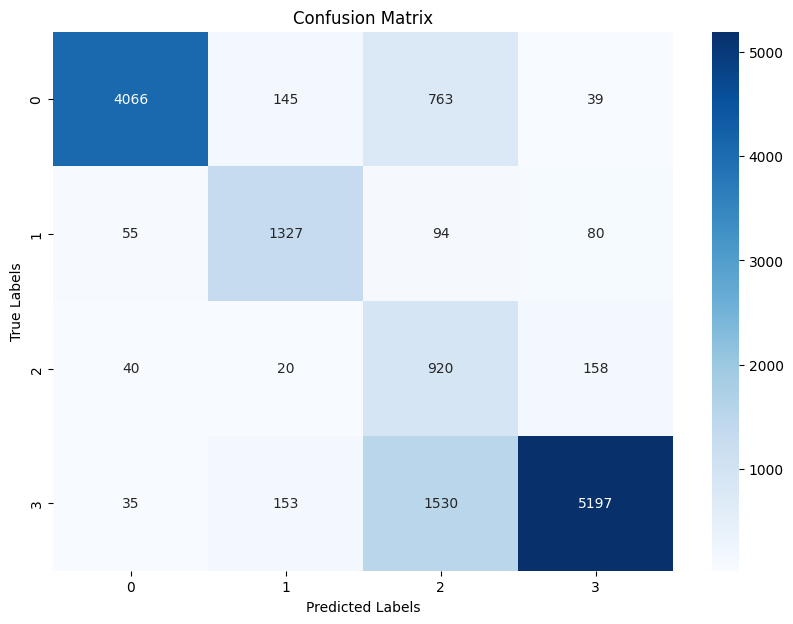

In [ ]:
test_labels = []
test_predictions = []

with torch.no_grad():
    for test_inputs, test_labels_batch in test_dataloader:
        test_inputs, test_labels_batch = test_inputs.to(device), test_labels_batch.to(device)

        test_labels_batch = torch.argmax(test_labels_batch, dim=1)
        test_outputs = model(test_inputs)
        _, predicted = torch.max(test_outputs, 1)

        test_labels.extend(test_labels_batch.cpu().numpy())
        test_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


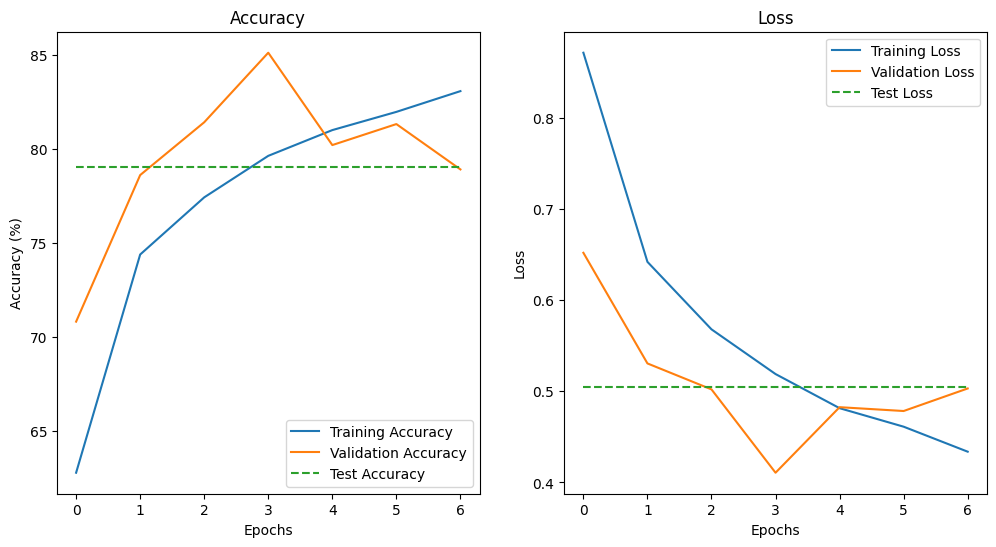

In [ ]:
import matplotlib.pyplot as plt

test_accuracy_per_epoch_early = [test_accuracy] * 7  
test_loss_per_epoch_early = [test_loss] * 7  

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(7), train_accuracies_early, label="Training Accuracy")
plt.plot(range(7), val_accuracies_early, label="Validation Accuracy")
plt.plot(range(7), test_accuracy_per_epoch_early, label="Test Accuracy", linestyle='--')  
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(7), train_losses_early, label="Training Loss")
plt.plot(range(7), val_losses_early, label="Validation Loss")
plt.plot(range(7), test_loss_per_epoch_early, label="Test Loss", linestyle='--')  
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


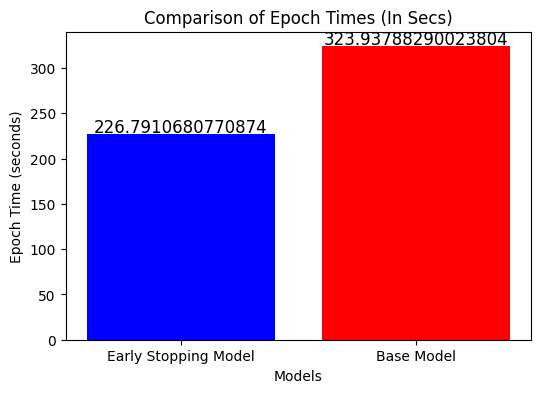

In [ ]:
import matplotlib.pyplot as plt


models = ['Early Stopping Model', 'Base Model']
times = [epoch_time_early, epoch_time_ce]

plt.figure(figsize=(6, 4))
plt.bar(models, times, color=['blue', 'red'])

plt.xlabel("Models")
plt.ylabel("Epoch Time (seconds)")
plt.title("Comparison of Epoch Times (In Secs)")

for i, v in enumerate(times):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12)

plt.show()


## Using Learning Rate Schedular

In [ ]:
from torch.optim.lr_scheduler import StepLR
import torch
import time
import numpy as np
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_lr = CustomCNNModel()
model_lr = model_lr.to(device)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = Adam(model_lr.parameters(), lr=0.001)

scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 10
start_time = time.time()

patience = 3
best_val_loss = np.inf
epochs_no_improve = 0
epoch_time_lr = 0

train_losses_lr, val_losses_lr = [], []
train_accuracies_lr, val_accuracies_lr = [], []

for epoch in range(epochs):
    model_lr.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        if labels.ndimension() > 1:
            labels = torch.argmax(labels, dim=1)

        outputs = model_lr(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = 100 * correct_predictions / total_predictions
    train_losses_lr.append(train_loss)
    train_accuracies_lr.append(train_accuracy)

    model_lr.eval()
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            if val_labels.ndimension() > 1:
                val_labels = torch.argmax(val_labels, dim=1)

            val_outputs = model_lr(val_inputs)
            loss = loss_function(val_outputs, val_labels)
            val_loss += loss.item()

            _, predicted = torch.max(val_outputs, 1)
            total_predictions += val_labels.size(0)
            correct_predictions += (predicted == val_labels).sum().item()

    val_loss /= len(val_dataloader)
    val_accuracy = 100 * correct_predictions / total_predictions
    val_losses_lr.append(val_loss)
    val_accuracies_lr.append(val_accuracy)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_lr.state_dict(), "best_model_lr.pth")

    epoch_time_lr = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f}")
    print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}% || Time: {epoch_time_lr//60:.0f}m {epoch_time_lr%60:.0f}s")

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time // 60:.0f}m {training_time % 60:.0f}s")


Using device: cuda
Epoch [1/10] | LR: 0.001000
Training Loss: 0.8671, Training Accuracy: 63.20%
Validation Loss: 0.6666, Validation Accuracy: 73.69% || Time: 0m 33s
Epoch [2/10] | LR: 0.001000
Training Loss: 0.6500, Training Accuracy: 73.95%
Validation Loss: 0.5676, Validation Accuracy: 76.92% || Time: 1m 14s
Epoch [3/10] | LR: 0.001000
Training Loss: 0.5721, Training Accuracy: 77.30%
Validation Loss: 0.5410, Validation Accuracy: 78.12% || Time: 1m 46s
Epoch [4/10] | LR: 0.001000
Training Loss: 0.5154, Training Accuracy: 79.76%
Validation Loss: 0.4652, Validation Accuracy: 82.03% || Time: 2m 25s
Epoch [5/10] | LR: 0.000500
Training Loss: 0.4852, Training Accuracy: 81.05%
Validation Loss: 0.4888, Validation Accuracy: 79.83% || Time: 2m 57s
Epoch [6/10] | LR: 0.000500
Training Loss: 0.4311, Training Accuracy: 83.20%
Validation Loss: 0.3881, Validation Accuracy: 85.14% || Time: 3m 38s
Epoch [7/10] | LR: 0.000500
Training Loss: 0.4119, Training Accuracy: 84.01%
Validation Loss: 0.3822, Val

In [ ]:
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

model.load_state_dict(torch.load("best_model_lr.pth", map_location=device), strict=False)
model.to(device)
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

all_logits = []
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for test_inputs, test_labels in test_dataloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        if test_labels.ndimension() > 1:
            true_labels = torch.argmax(test_labels, dim=1)
        else:
            true_labels = test_labels

        test_outputs = model(test_inputs)
        loss = loss_function(test_outputs, true_labels)
        test_loss += loss.item()

        _, predicted = torch.max(test_outputs, 1)

        total_predictions += true_labels.size(0)
        correct_predictions += (predicted == true_labels).sum().item()

        all_logits.append(test_outputs.cpu().numpy()) 
        all_true_labels.extend(true_labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())

test_predictions = np.vstack(all_logits)
test_labels = np.array(all_true_labels)

test_accuracy = 100 * correct_predictions / total_predictions
test_loss = test_loss / len(test_dataloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predicted_labels, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Shape of test_predictions: {test_predictions.shape}")

<ipython-input-84-39b1e43e2bd5>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_lr.pth", map_location=device), strict=False)


Test Loss: 0.3756
Test Accuracy: 85.72%
Precision: 0.7788
Recall: 0.8223
F1 Score: 0.7894
Shape of test_predictions: (14622, 4)


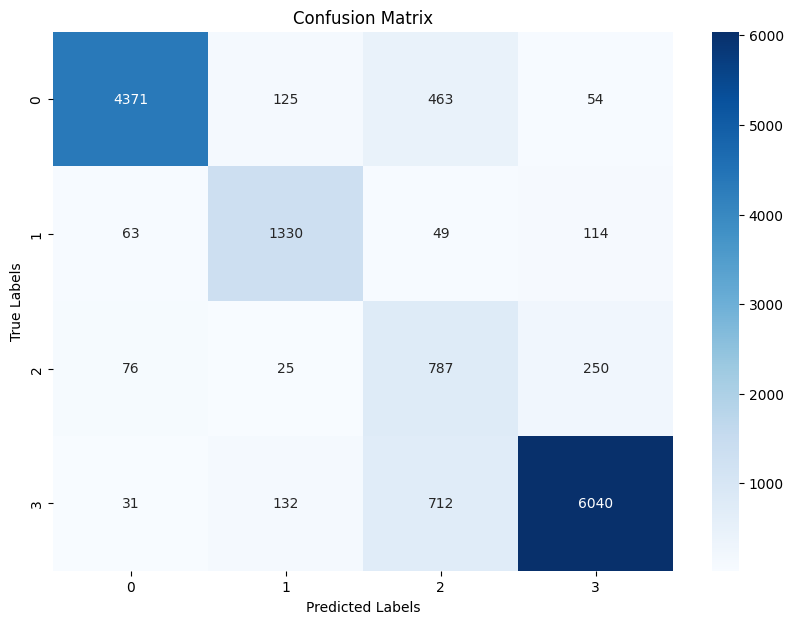

In [ ]:
test_labels = []
test_predictions = []

with torch.no_grad():
    for test_inputs, test_labels_batch in test_dataloader:
        test_inputs, test_labels_batch = test_inputs.to(device), test_labels_batch.to(device)

        test_labels_batch = torch.argmax(test_labels_batch, dim=1)
        test_outputs = model(test_inputs)
        _, predicted = torch.max(test_outputs, 1)

        test_labels.extend(test_labels_batch.cpu().numpy())  
        test_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


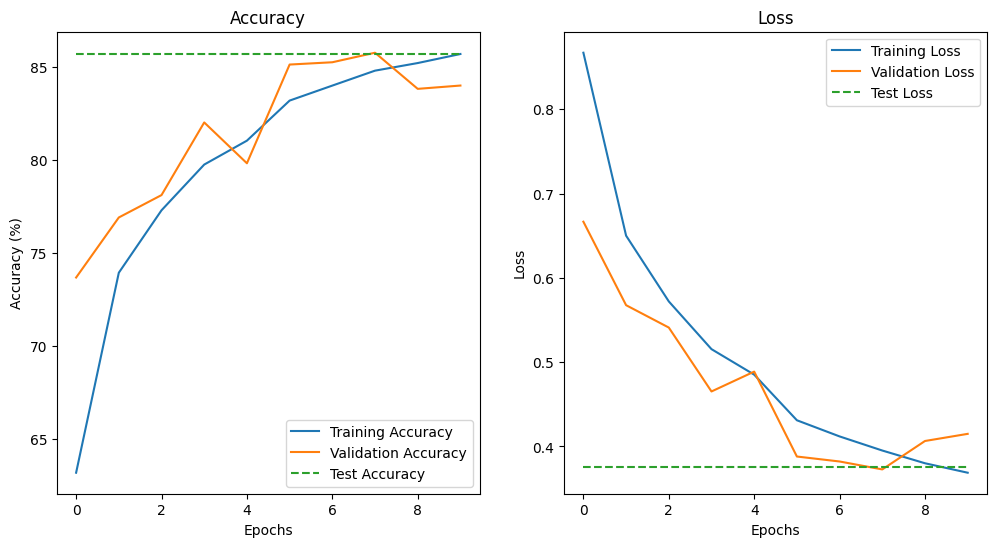

In [ ]:
import matplotlib.pyplot as plt

test_accuracy_per_epoch_lr = [test_accuracy] * epochs  
test_loss_per_epoch_lr = [test_loss] * epochs  

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_accuracies_lr, label="Training Accuracy")
plt.plot(range(epochs), val_accuracies_lr, label="Validation Accuracy")
plt.plot(range(epochs), test_accuracy_per_epoch_lr, label="Test Accuracy", linestyle='--') 
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_losses_lr, label="Training Loss")
plt.plot(range(epochs), val_losses_lr, label="Validation Loss")
plt.plot(range(epochs), test_loss_per_epoch_lr, label="Test Loss", linestyle='--') 
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


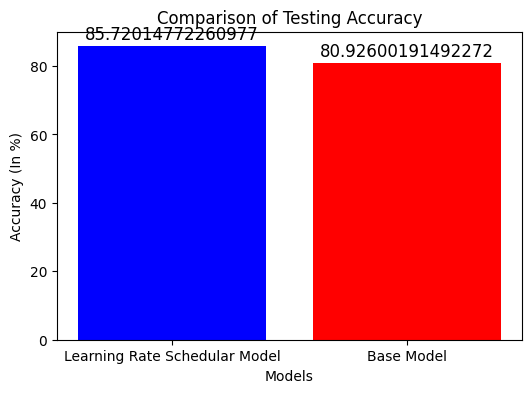

In [ ]:
import matplotlib.pyplot as plt


models = ['Learning Rate Schedular Model', 'Base Model']
times = [test_accuracy_per_epoch_lr[0], test_accuracy_per_epoch_ce[0]]

plt.figure(figsize=(6, 4))
plt.bar(models, times, color=['blue', 'red'])

plt.xlabel("Models")
plt.ylabel("Accuracy (In %)")
plt.title("Comparison of Testing Accuracy")

for i, v in enumerate(times):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12)

plt.show()


## Using Gradient Accumulation Method

In [ ]:
import torch
import time
import numpy as np
from torch.optim import Adam

model_a = CustomCNNModel()
model_a = model_a.to(device)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = Adam(model_a.parameters(), lr=0.005)

epochs = 20
start_time = time.time()

patience = 3
best_val_loss = np.inf
epochs_no_improve = 0

accumulation_steps = 4

train_losses_a, val_losses_a = [], []
train_accuracies_a, val_accuracies_a = [], []

for epoch in range(epochs):
    model_a.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    optimizer.zero_grad()

    for i, (inputs, labels) in enumerate(train_dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        if labels.ndimension() > 1:
            labels = torch.argmax(labels, dim=1)

        outputs = model_a(inputs)
        loss = loss_function(outputs, labels)

        loss = loss / accumulation_steps

        loss.backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_dataloader):
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * accumulation_steps

        _, predicted = torch.max(outputs, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_accuracy = 100 * correct_predictions / total_predictions
    train_losses_a.append(train_loss)
    train_accuracies_a.append(train_accuracy)

    model_a.eval()
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            if val_labels.ndimension() > 1:
                val_labels = torch.argmax(val_labels, dim=1)

            val_outputs = model_a(val_inputs)
            loss = loss_function(val_outputs, val_labels)
            val_loss += loss.item()

            _, predicted = torch.max(val_outputs, 1)
            total_predictions += val_labels.size(0)
            correct_predictions += (predicted == val_labels).sum().item()

    val_loss = val_loss / len(val_dataloader)
    val_accuracy = 100 * correct_predictions / total_predictions
    val_losses_a.append(val_loss)
    val_accuracies_a.append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_a.state_dict(), "best_model_a.pth")

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}% || Time: {epoch_time//60:.0f}m {epoch_time%60:.0f}s")

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time // 60:.0f}m {training_time % 60:.0f}s")


Epoch [1/20] Training Loss: 1.0320, Training Accuracy: 53.99%
Validation Loss: 0.9164, Validation Accuracy: 59.79% || Time: 0m 33s
Epoch [2/20] Training Loss: 0.8066, Training Accuracy: 67.34%
Validation Loss: 0.7291, Validation Accuracy: 69.53% || Time: 1m 5s
Epoch [3/20] Training Loss: 0.7628, Training Accuracy: 69.16%
Validation Loss: 0.6431, Validation Accuracy: 74.48% || Time: 1m 36s
Epoch [4/20] Training Loss: 0.7360, Training Accuracy: 70.31%
Validation Loss: 0.7821, Validation Accuracy: 67.30% || Time: 2m 8s
Epoch [5/20] Training Loss: 0.7267, Training Accuracy: 70.74%
Validation Loss: 0.6840, Validation Accuracy: 71.39% || Time: 2m 49s
Epoch [6/20] Training Loss: 0.7160, Training Accuracy: 71.13%
Validation Loss: 0.7139, Validation Accuracy: 71.26% || Time: 3m 21s
Epoch [7/20] Training Loss: 0.6990, Training Accuracy: 72.26%
Validation Loss: 0.6311, Validation Accuracy: 75.53% || Time: 3m 52s
Epoch [8/20] Training Loss: 0.6882, Training Accuracy: 72.68%
Validation Loss: 0.5834

In [90]:
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

model.load_state_dict(torch.load("best_model_a.pth", map_location=device), strict=False)
model.to(device)
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

all_logits = []
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for test_inputs, test_labels in test_dataloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        if test_labels.ndimension() > 1:
            true_labels = torch.argmax(test_labels, dim=1)
        else:
            true_labels = test_labels

        test_outputs = model(test_inputs)
        loss = loss_function(test_outputs, true_labels)
        test_loss += loss.item()

        _, predicted = torch.max(test_outputs, 1)

        total_predictions += true_labels.size(0)
        correct_predictions += (predicted == true_labels).sum().item()

        all_logits.append(test_outputs.cpu().numpy())
        all_true_labels.extend(true_labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())

test_predictions = np.vstack(all_logits)
test_labels = np.array(all_true_labels)

test_accuracy = 100 * correct_predictions / total_predictions
test_loss = test_loss / len(test_dataloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predicted_labels, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Shape of test_predictions: {test_predictions.shape}")

<ipython-input-90-febdc4edb7db>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_a.pth", map_location=device), strict=False)


Test Loss: 0.5218
Test Accuracy: 80.80%
Precision: 0.6962
Recall: 0.7428
F1 Score: 0.7130
Shape of test_predictions: (14622, 4)


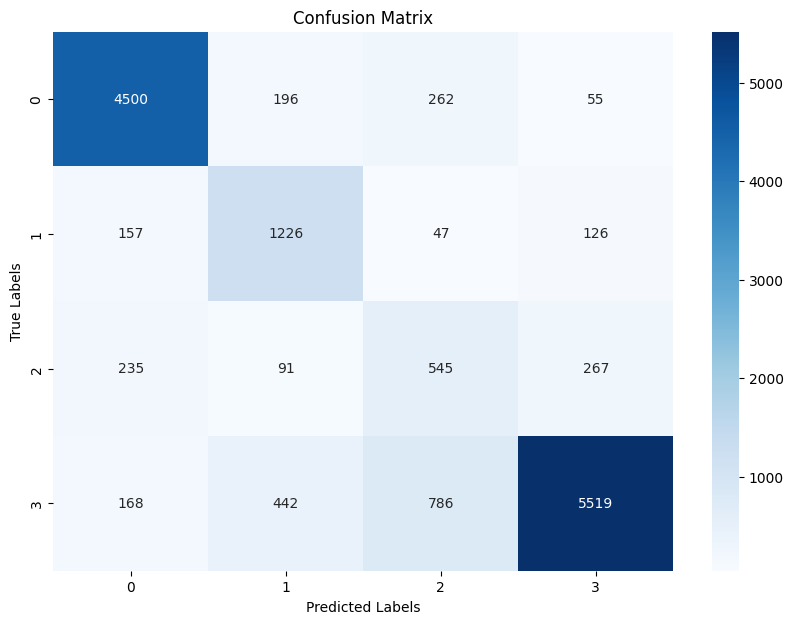

In [91]:
test_labels = []
test_predictions = []

with torch.no_grad():
    for test_inputs, test_labels_batch in test_dataloader:
        test_inputs, test_labels_batch = test_inputs.to(device), test_labels_batch.to(device)

        test_labels_batch = torch.argmax(test_labels_batch, dim=1)
        test_outputs = model(test_inputs)
        _, predicted = torch.max(test_outputs, 1)

        test_labels.extend(test_labels_batch.cpu().numpy())
        test_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


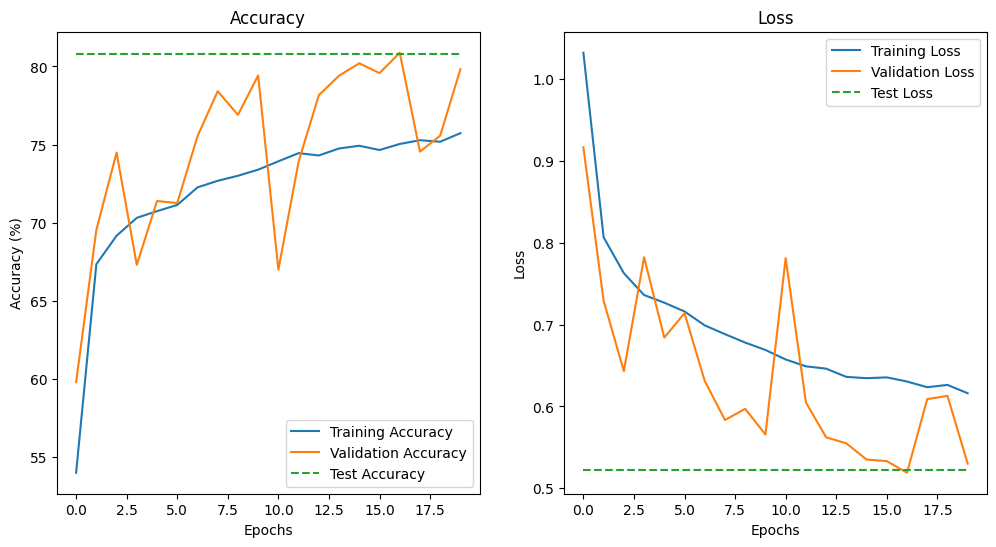

In [92]:
import matplotlib.pyplot as plt

test_accuracy_per_epoch_a = [test_accuracy] * epochs
test_loss_per_epoch_a = [test_loss] * epochs

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_accuracies_a, label="Training Accuracy")
plt.plot(range(epochs), val_accuracies_a, label="Validation Accuracy")
plt.plot(range(epochs), test_accuracy_per_epoch_a, label="Test Accuracy", linestyle='--')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs), train_losses_a, label="Training Loss")
plt.plot(range(epochs), val_losses_a, label="Validation Loss")
plt.plot(range(epochs), test_loss_per_epoch_a, label="Test Loss", linestyle='--')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


## K Fold Cross Validation Method

In [ ]:
import torch
import time
import numpy as np
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold

k_folds = 5

dataset_size = len(train_dataset)
targets = np.array([np.argmax(train_dataset[i][1]) for i in range(dataset_size)])

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_train_losses, fold_val_losses = [], []
fold_train_accuracies, fold_val_accuracies = [], []

best_overall_val_loss = np.inf
best_model = None

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(dataset_size), targets)):
    print(f"\n{'='*20} Fold {fold+1}/{k_folds} {'='*20}")

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=False)

    model_k = CustomCNNModel().to(device)
    loss_function = torch.nn.CrossEntropyLoss()
    optimizer = Adam(model_k.parameters(), lr=0.005)

    patience = 3
    best_val_loss = np.inf
    epochs_no_improve = 0
    epochs = 5

    train_losses_ce, val_losses_ce = [], []
    train_accuracies_ce, val_accuracies_ce = [], []

    for epoch in range(epochs):
        start_time = time.time()

        model_k.train()
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            if labels.ndimension() > 1:
                labels = torch.argmax(labels, dim=1)

            outputs = model_k(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_dataloader)
        train_accuracy = 100 * correct_predictions / total_predictions
        train_losses_ce.append(train_loss)
        train_accuracies_ce.append(train_accuracy)

        model_k.eval()
        val_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad():
            for val_inputs, val_labels in val_dataloader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

                if val_labels.ndimension() > 1:
                    val_labels = torch.argmax(val_labels, dim=1)

                val_outputs = model_k(val_inputs)
                loss = loss_function(val_outputs, val_labels)
                val_loss += loss.item()
                _, predicted = torch.max(val_outputs, 1)
                total_predictions += val_labels.size(0)
                correct_predictions += (predicted == val_labels).sum().item()

        val_loss = val_loss / len(val_dataloader)
        val_accuracy = 100 * correct_predictions / total_predictions
        val_losses_ce.append(val_loss)
        val_accuracies_ce.append(val_accuracy)

        epoch_time = time.time() - start_time

        print(f"Epoch [{epoch+1}/{epochs}] Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}% || Time: {epoch_time//60:.0f}m {epoch_time%60:.0f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model_k.state_dict(), f"best_model_fold{fold+1}.pth")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered!")
                break

    fold_train_losses.append(train_losses_ce[-1])
    fold_val_losses.append(val_losses_ce[-1])
    fold_train_accuracies.append(train_accuracies_ce[-1])
    fold_val_accuracies.append(val_accuracies_ce[-1])

    if best_val_loss < best_overall_val_loss:
        best_overall_val_loss = best_val_loss
        best_model = model_k

print("\nK-Fold Cross Validation Results")
print(f"Average Train Loss: {np.mean(fold_train_losses):.4f}")
print(f"Average Validation Loss: {np.mean(fold_val_losses):.4f}")
print(f"Average Train Accuracy: {np.mean(fold_train_accuracies):.2f}%")
print(f"Average Validation Accuracy: {np.mean(fold_val_accuracies):.2f}%")


torch.save(best_model.state_dict(), "best_model_K.pth")



==================== Fold 1/5 ====================
Epoch [1/5] Training Loss: 1.1654, Training Accuracy: 46.99%
Validation Loss: 1.1596, Validation Accuracy: 47.22% || Time: 0m 28s
Epoch [2/5] Training Loss: 1.1616, Training Accuracy: 47.22%
Validation Loss: 1.1596, Validation Accuracy: 47.22% || Time: 0m 27s
Epoch [3/5] Training Loss: 1.1600, Training Accuracy: 47.22%
Validation Loss: 1.1591, Validation Accuracy: 47.22% || Time: 0m 27s
Epoch [4/5] Training Loss: 1.1597, Training Accuracy: 47.22%
Validation Loss: 1.1596, Validation Accuracy: 47.22% || Time: 0m 27s
Epoch [5/5] Training Loss: 1.1596, Training Accuracy: 47.22%
Validation Loss: 1.1596, Validation Accuracy: 47.22% || Time: 0m 27s

==================== Fold 2/5 ====================
Epoch [1/5] Training Loss: 0.7821, Training Accuracy: 72.15%
Validation Loss: 0.6538, Validation Accuracy: 77.01% || Time: 0m 27s
Epoch [2/5] Training Loss: 0.6644, Training Accuracy: 77.34%
Validation Loss: 0.5948, Validation Accuracy: 79.09% ||

In [95]:
import torch
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

model.load_state_dict(torch.load("best_model_K.pth", map_location=device), strict=False)
model.to(device)
model.eval()

test_loss = 0.0
correct_predictions = 0
total_predictions = 0

all_logits = []
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for test_inputs, test_labels in test_dataloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)

        if test_labels.ndimension() > 1:
            true_labels = torch.argmax(test_labels, dim=1)
        else:
            true_labels = test_labels

        test_outputs = model(test_inputs)
        loss = loss_function(test_outputs, true_labels)
        test_loss += loss.item()

        _, predicted = torch.max(test_outputs, 1)

        total_predictions += true_labels.size(0)
        correct_predictions += (predicted == true_labels).sum().item()

        all_logits.append(test_outputs.cpu().numpy())
        all_true_labels.extend(true_labels.cpu().numpy())
        all_predicted_labels.extend(predicted.cpu().numpy())

test_predictions = np.vstack(all_logits)
test_labels = np.array(all_true_labels)

test_accuracy = 100 * correct_predictions / total_predictions
test_loss = test_loss / len(test_dataloader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predicted_labels, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Shape of test_predictions: {test_predictions.shape}")

<ipython-input-95-8646b5e78079>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_K.pth", map_location=device), strict=False)


Test Loss: 0.5562
Test Accuracy: 81.29%
Precision: 0.6013
Recall: 0.5951
F1 Score: 0.5921
Shape of test_predictions: (14622, 4)


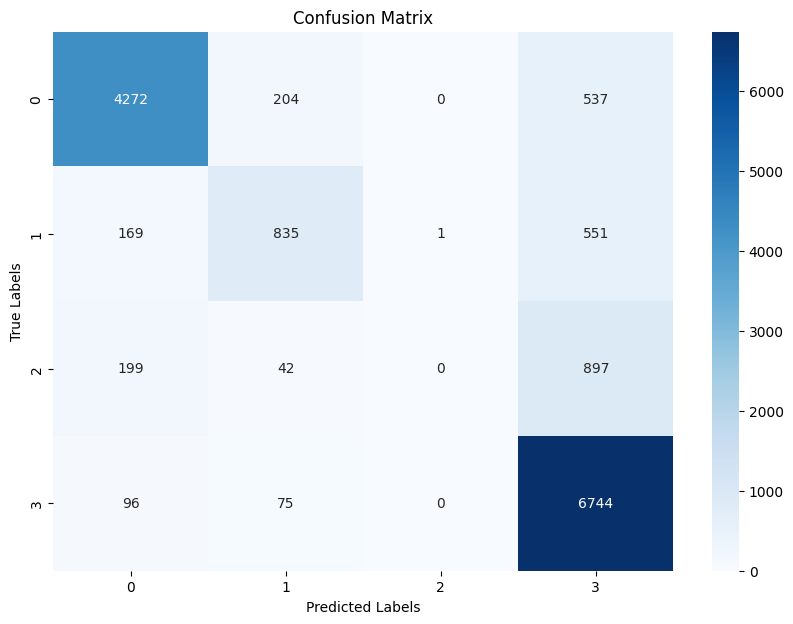

In [96]:
test_labels = []
test_predictions = []

with torch.no_grad():
    for test_inputs, test_labels_batch in test_dataloader:
        test_inputs, test_labels_batch = test_inputs.to(device), test_labels_batch.to(device)

        test_labels_batch = torch.argmax(test_labels_batch, dim=1)
        test_outputs = model(test_inputs)
        _, predicted = torch.max(test_outputs, 1)

        test_labels.extend(test_labels_batch.cpu().numpy())
        test_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


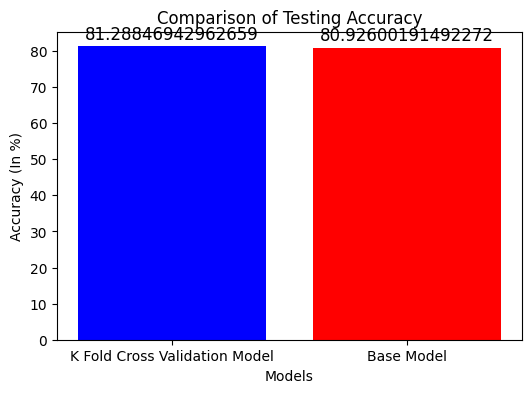

In [ ]:
import matplotlib.pyplot as plt


models = ['K Fold Cross Validation Model', 'Base Model']
times = [test_accuracy, test_accuracy_per_epoch_ce[0]]

plt.figure(figsize=(6, 4))
plt.bar(models, times, color=['blue', 'red'])

plt.xlabel("Models")
plt.ylabel("Accuracy (In %)")
plt.title("Comparison of Testing Accuracy")

for i, v in enumerate(times):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12)

plt.show()


## Accuracy Comparison for all trainings using different loss functions and methods

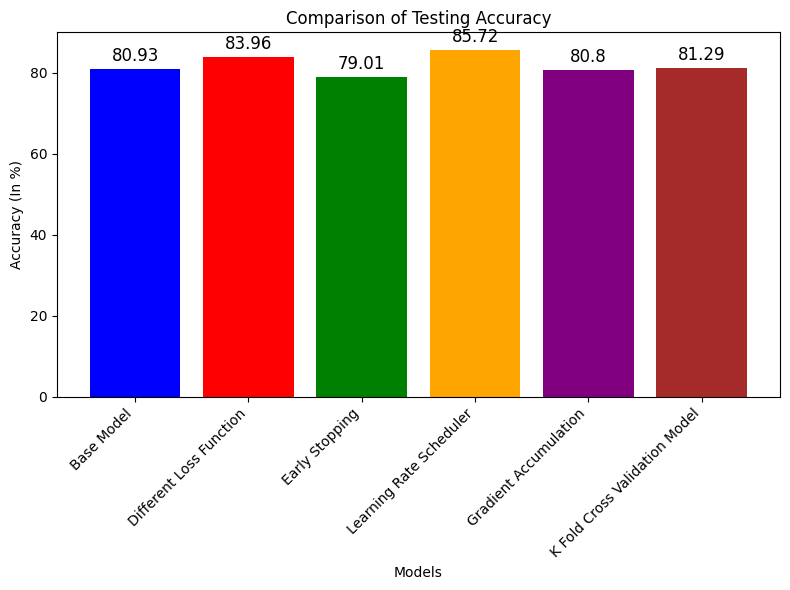

In [ ]:
import matplotlib.pyplot as plt

models = ['Base Model', 'Different Loss Function', 'Early Stopping', 'Learning Rate Scheduler', 'Gradient Accumulation', 'K Fold Cross Validation Model']
times = [test_accuracy_per_epoch_ce[0], test_accuracy_per_epoch_focal[0], test_accuracy_per_epoch_early[0], test_accuracy_per_epoch_lr[0], test_accuracy_per_epoch_a[0], test_accuracy]

plt.figure(figsize=(8, 6))  
plt.bar(models, times, color=['blue', 'red', 'green', 'orange', 'purple', 'brown'])

plt.xlabel("Models")
plt.ylabel("Accuracy (In %)")
plt.title("Comparison of Testing Accuracy")

for i, v in enumerate(times):
    plt.text(i, v + 2, str(round(v, 2)), ha='center', fontsize=12)

plt.xticks(rotation=45, ha="right")  
plt.tight_layout()  

plt.show()
